# Notebook 1 — NSE Data Foundation

**Goal:** Build a clean, unified dataset from 18 years of NSE historical CSVs (2007-2024),
merge sector classifications, run data quality diagnostics, and compute baseline quant
features (returns, volatility, moving averages).

This notebook is the foundation for everything that follows — regime detection, signal
testing, and portfolio construction. Jim Simons' first rule: *clean data before clever models.*

### Sections
1. Configuration and imports
2. Load and normalize all historical CSVs into canonical schema
3. Build ticker master map from sector classification files
4. Data quality diagnostics
5. Coverage heatmap (tickers x years)
6. Return distributions (daily / weekly / monthly)
7. Volatility and drawdown profiles by sector
8. Cross-sectional leaders and laggards
9. Save artifacts (parquet + markdown reports)

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

PROJECT_ROOT = Path("..").resolve()
NSE_DATA_DIR = PROJECT_ROOT / "NSE_DATA"
RESEARCH_DATA = PROJECT_ROOT / "research" / "data"
RESEARCH_REPORTS = PROJECT_ROOT / "research" / "reports"
RESEARCH_DATA.mkdir(parents=True, exist_ok=True)
RESEARCH_REPORTS.mkdir(parents=True, exist_ok=True)

STOCK_YEARS = list(range(2007, 2025))

print(f"Project root : {PROJECT_ROOT}")
print(f"NSE data dir : {NSE_DATA_DIR}")
print(f"CSV files    : {len(list(NSE_DATA_DIR.glob('NSE_data_all_stocks_*.csv')))}")
print(f"Sector files : {len(list(NSE_DATA_DIR.glob('NSE_data_stock_market_sectors_*.csv')))}")

Project root : D:\2026 Projects\Nairobi-stock-Exchange
NSE data dir : D:\2026 Projects\Nairobi-stock-Exchange\NSE_DATA
CSV files    : 18
Sector files : 5


## 2. Load and Normalize All Historical CSVs

The 18 CSV files have schema drift across years:
- Column headers: `DATE` vs `Date`, `Adjust` vs `Adjusted Price`
- Date formats: `1/2/2007`, `02-Jan-20`, `2-Jan-24`
- Numbers: commas in volume (`"7,800"`), `-` for missing values
- Index rows mixed in (tickers starting with `^`)

We normalize everything into one long-form table:
`date | ticker | name | close | low | high | prev_close | change_abs | change_pct | volume | source_year`

In [2]:
CANONICAL_COLS = {
    "date": "date",
    "ticker": "ticker",
    "name": "name",
    "close": "close",
    "low": "low",
    "high": "high",
    "prev_close": "prev_close",
    "change_abs": "change_abs",
    "change_pct": "change_pct",
    "volume": "volume",
    "source_year": "source_year",
}

# Legacy ticker aliases: old CODE -> canonical ticker
TICKER_ALIASES: dict[str, str] = {
    "BBK": "ABSA",       # Barclays Bank Kenya -> ABSA Bank Kenya (rebranded 2020)
    "CFC": "SBIC",       # CFC Stanbic -> Stanbic Holdings
    "NIC": "NCBA",       # NIC Bank merged into NCBA Group (2019)
    "FIRE": "SMER",      # Sameer Africa was listed under FIRE
    "C&G": "CGEN",       # Car and General
    "CMC": "CMC",        # CMC Holdings (delisted — keep as-is)
    "KENO": "KENO",      # KenolKobil (merged into Rubis/delisted)
    "UTK": "UTK",        # Unilever Tea Kenya (delisted)
    "REA": "REA",        # Rea Vipingo (delisted)
    "FAHR": "LAPR",      # Stanlib Fahari -> Laptrust Imara I-REIT
}


def _clean_numeric(s: pd.Series) -> pd.Series:
    """Convert a column to float, handling commas, dashes, and percent signs."""
    return pd.to_numeric(
        s.astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("%", "", regex=False)
        .str.replace("-", "", regex=False)
        .str.strip(),
        errors="coerce",
    )


def load_single_year(year: int) -> pd.DataFrame:
    """Load one year's CSV and normalize to canonical schema."""
    path = NSE_DATA_DIR / f"NSE_data_all_stocks_{year}.csv"
    if not path.exists():
        print(f"  [SKIP] {path.name} not found")
        return pd.DataFrame()

    df = pd.read_csv(path, dtype=str)
    df.columns = df.columns.str.strip()

    # Normalize column names
    col_map: dict[str, str] = {}
    for c in df.columns:
        cl = c.lower().strip()
        if cl in ("date",):
            col_map[c] = "date"
        elif cl in ("code",):
            col_map[c] = "ticker"
        elif cl in ("name",):
            col_map[c] = "name"
        elif cl in ("day price",):
            col_map[c] = "close"
        elif cl in ("day low",):
            col_map[c] = "low"
        elif cl in ("day high",):
            col_map[c] = "high"
        elif cl in ("previous",):
            col_map[c] = "prev_close"
        elif cl in ("change",) and "%" not in cl:
            col_map[c] = "change_abs"
        elif cl in ("change%",):
            col_map[c] = "change_pct"
        elif cl in ("volume",):
            col_map[c] = "volume"

    df = df.rename(columns=col_map)
    needed = ["date", "ticker", "name", "close", "low", "high", "prev_close",
              "change_abs", "change_pct", "volume"]
    for col in needed:
        if col not in df.columns:
            df[col] = np.nan

    df = df[needed].copy()

    # Filter out index rows (tickers starting with ^)
    df = df[~df["ticker"].astype(str).str.startswith("^")].copy()

    # Strip whitespace
    df["ticker"] = df["ticker"].astype(str).str.strip()
    df["name"] = df["name"].astype(str).str.strip()

    # Apply ticker aliases
    df["ticker"] = df["ticker"].replace(TICKER_ALIASES)

    # Parse dates — multiple formats across years
    df["date"] = pd.to_datetime(df["date"], format="mixed", dayfirst=True, errors="coerce")

    # Clean numeric columns
    for col in ["close", "low", "high", "prev_close", "change_abs", "change_pct", "volume"]:
        df[col] = _clean_numeric(df[col])

    df["source_year"] = year
    df = df.dropna(subset=["date", "ticker"]).reset_index(drop=True)
    return df


# Load all years
frames: list[pd.DataFrame] = []
for yr in STOCK_YEARS:
    chunk = load_single_year(yr)
    if not chunk.empty:
        frames.append(chunk)
        print(f"  {yr}: {len(chunk):>7,} rows, {chunk['ticker'].nunique():>3} tickers")

prices = pd.concat(frames, ignore_index=True)
prices = prices.sort_values(["date", "ticker"]).reset_index(drop=True)

print(f"\n{'='*60}")
print(f"Total rows     : {len(prices):>10,}")
print(f"Date range     : {prices['date'].min().date()} → {prices['date'].max().date()}")
print(f"Unique tickers : {prices['ticker'].nunique()}")
print(f"Unique dates   : {prices['date'].dt.date.nunique()}")

  2007:  10,360 rows,  54 tickers


  2008:  10,123 rows,  54 tickers


  2009:  13,888 rows,  57 tickers


  2010:  14,452 rows,  61 tickers


  2011:  14,445 rows,  59 tickers


...

  2021:  16,000 rows,  64 tickers


  2022:  16,092 rows,  66 tickers


  2023:  15,983 rows,  66 tickers


  2024:  16,449 rows,  67 tickers

Total rows     :    267,527
Date range     : 2007-01-02 → 2024-12-31
Unique tickers : 88


Unique dates   : 4478


## 3. Build Ticker Master Map from Sector Files

Merge all five sector classification files into a single canonical map. Use the most recent
sector file as authority, with older files filling in historical tickers that may have been
delisted.

In [3]:
SECTOR_FILES = sorted(NSE_DATA_DIR.glob("NSE_data_stock_market_sectors_*.csv"))

sector_frames: list[pd.DataFrame] = []
for sf in SECTOR_FILES:
    sdf = pd.read_csv(sf, dtype=str)
    sdf.columns = sdf.columns.str.strip().str.lower()

    # Normalize column names across files
    rename = {}
    for c in sdf.columns:
        if c in ("code", "stock_code"):
            rename[c] = "ticker"
        elif c in ("name", "stock_name"):
            rename[c] = "name"
        elif c == "sector":
            rename[c] = "sector"
    sdf = sdf.rename(columns=rename)

    if "ticker" not in sdf.columns or "sector" not in sdf.columns:
        continue

    sdf = sdf[["sector", "ticker", "name"]].dropna(subset=["ticker", "sector"])
    sdf["ticker"] = sdf["ticker"].str.strip()
    sdf["sector"] = sdf["sector"].str.strip()
    sdf["name"] = sdf["name"].astype(str).str.strip()

    # Skip index rows and empty tickers
    sdf = sdf[~sdf["ticker"].str.startswith("^")]
    sdf = sdf[sdf["ticker"] != ""]
    sdf = sdf[sdf["sector"].str.lower() != "indices"]

    # Fix corruption in 2023_2024 file: "Energy and Petroleum" appears as a
    # ticker under "Construction and Allied" instead of being a sector header.
    sdf = sdf[sdf["ticker"] != "Energy and Petroleum"]

    # Extract approximate year from filename
    fname = sf.stem
    year_part = fname.split("sectors_")[-1]
    sdf["sector_file_year"] = year_part

    sector_frames.append(sdf)

all_sectors = pd.concat(sector_frames, ignore_index=True)

# Apply same ticker aliases
all_sectors["ticker"] = all_sectors["ticker"].replace(TICKER_ALIASES)

# Fix tickers that ended up under wrong sector due to the 2023_2024 file corruption
SECTOR_OVERRIDES = {
    "KEGN": "Energy and Petroleum",
    "KPLC": "Energy and Petroleum",
    "KPLC-P4": "Energy and Petroleum",
    "KPLC-P7": "Energy and Petroleum",
    "TOTL": "Energy and Petroleum",
    "UMME": "Energy and Petroleum",
    "KENO": "Energy and Petroleum",
    "SCOM": "Telecommunication",
}
for ticker, correct_sector in SECTOR_OVERRIDES.items():
    all_sectors.loc[all_sectors["ticker"] == ticker, "sector"] = correct_sector

# Keep most-recent sector assignment per ticker
all_sectors = all_sectors.sort_values("sector_file_year", ascending=False)
ticker_master = all_sectors.drop_duplicates(subset="ticker", keep="first").copy()
ticker_master = ticker_master[["ticker", "name", "sector"]].reset_index(drop=True)

# Mark active vs inactive using actual price data
active_tickers = set(prices[prices["source_year"] >= 2023]["ticker"].unique())
ticker_master["active"] = ticker_master["ticker"].isin(active_tickers)

# Add any tickers in price data but not in sector files
price_tickers = set(prices["ticker"].unique())
sector_tickers = set(ticker_master["ticker"].unique())
missing = price_tickers - sector_tickers
if missing:
    extra = pd.DataFrame({
        "ticker": list(missing),
        "name": [prices[prices["ticker"] == t]["name"].iloc[0] if len(prices[prices["ticker"] == t]) > 0 else t for t in missing],
        "sector": "Unknown",
        "active": [t in active_tickers for t in missing],
    })
    ticker_master = pd.concat([ticker_master, extra], ignore_index=True)

ticker_master = ticker_master.sort_values("ticker").reset_index(drop=True)

print(f"Ticker master: {len(ticker_master)} tickers ({ticker_master['active'].sum()} active)")
print(f"\nSector breakdown:")
print(ticker_master.groupby("sector")["ticker"].count().sort_values(ascending=False).to_string())

Ticker master: 88 tickers (67 active)

Sector breakdown:
sector
Unknown                          21
Commercial and Services          13
Banking                          12
Manufacturing and Allied          8
Energy and Petroleum              7
Agricultural                      6
Insurance                         6
Construction and Allied           5
Investment                        5
Automobiles and Accessories       1
Exchange Traded Funds             1
Investment Services               1
Real Estate Investment Trusts     1
Telecommunication                 1


In [4]:
# Merge sector info onto price data
prices = prices.merge(
    ticker_master[["ticker", "sector"]],
    on="ticker",
    how="left",
)
prices["sector"] = prices["sector"].fillna("Unknown")

print(f"Prices with sector: {prices['sector'].notna().sum() / len(prices) * 100:.1f}% mapped")
print(f"\nSample of unified dataset:")
prices.sample(8, random_state=42)[["date", "ticker", "name", "close", "volume", "sector", "source_year"]]

Prices with sector: 100.0% mapped

Sample of unified dataset:


,date,ticker,name,close,volume,sector,source_year
126129,2016-03-17,NMG,Nation Media Group Plc,180.00,6200.0,Commercial and Services,2016
59680,2011-10-01,NMG,Nation Media Group,174.00,844600.0,Commercial and Services,2011
250074,2023-12-05,SCAN,WPP ScanGroup Plc,2.13,1500.0,Commercial and Services,2023
6059,2007-07-30,SCAN,ScanGroup,26.75,159300.0,Commercial and Services,2007
30449,2009-09-15,UNGA,Unga Group,9.50,900.0,Manufacturing and Allied,2009
163611,2018-07-30,NBK,National Bank of Kenya Ltd,6.05,9800.0,Banking,2018
100948,2014-07-24,CRWN,Crown Paints Kenya Plc,98.00,NaN,Construction and Allied,2014
257366,2024-05-21,EQTY,Equity Group Holdings Plc,47.00,1429100.0,Banking,2024


## 4. Data Quality Diagnostics

Check for:
- Duplicate (date, ticker) pairs
- Missing / non-positive prices
- Volume anomalies (zeros, NaN)
- Change vs. price consistency
- Coverage gaps per ticker per year

In [5]:
total = len(prices)

# Duplicates
dupes = prices.duplicated(subset=["date", "ticker"], keep=False)
n_dupes = dupes.sum()

# Missing close prices
missing_close = prices["close"].isna().sum()

# Non-positive prices
non_positive = (prices["close"] <= 0).sum()

# Missing volume
missing_vol = prices["volume"].isna().sum()
zero_vol = (prices["volume"] == 0).sum()

# Rows where close exists
has_close = prices["close"].notna()

# Change consistency: where we have close and prev_close, check if change_abs ≈ close - prev_close
has_both = prices["close"].notna() & prices["prev_close"].notna() & prices["change_abs"].notna()
if has_both.any():
    computed_change = prices.loc[has_both, "close"] - prices.loc[has_both, "prev_close"]
    actual_change = prices.loc[has_both, "change_abs"]
    mismatch = (computed_change - actual_change).abs() > 0.5
    n_change_mismatch = mismatch.sum()
else:
    n_change_mismatch = 0

valid_rows = total - missing_close - n_dupes // 2
completeness = valid_rows / total * 100

quality_report = {
    "total_rows": total,
    "valid_rows_approx": valid_rows,
    "duplicate_date_ticker_pairs": n_dupes,
    "missing_close_price": int(missing_close),
    "non_positive_close": int(non_positive),
    "missing_volume": int(missing_vol),
    "zero_volume": int(zero_vol),
    "change_vs_price_mismatch": int(n_change_mismatch),
    "completeness_pct": round(completeness, 2),
}

print("=== Data Quality Report ===")
for k, v in quality_report.items():
    print(f"  {k:35s}: {v:>10,}" if isinstance(v, int) else f"  {k:35s}: {v:>10}")

# Remove exact duplicates (keep first), drop rows without close price
before = len(prices)
prices = prices.drop_duplicates(subset=["date", "ticker"], keep="first")
prices = prices[prices["close"].notna() & (prices["close"] > 0)].copy()
prices = prices.sort_values(["ticker", "date"]).reset_index(drop=True)
after = len(prices)
print(f"\nCleaned: {before:,} → {after:,} rows ({before - after:,} removed)")

=== Data Quality Report ===
  total_rows                         :    267,527
  valid_rows_approx                  :     267310
  duplicate_date_ticker_pairs        :        432
  missing_close_price                :          1
  non_positive_close                 :          0
  missing_volume                     :     46,136
  zero_volume                        :     14,347
  change_vs_price_mismatch           :     40,367
  completeness_pct                   :      99.92



Cleaned: 267,527 → 267,310 rows (217 removed)


## 5. Coverage Heatmap (Tickers x Years)

Which stocks were actively traded in which years? This reveals delistings, new listings,
and data gaps that could bias any backtest.

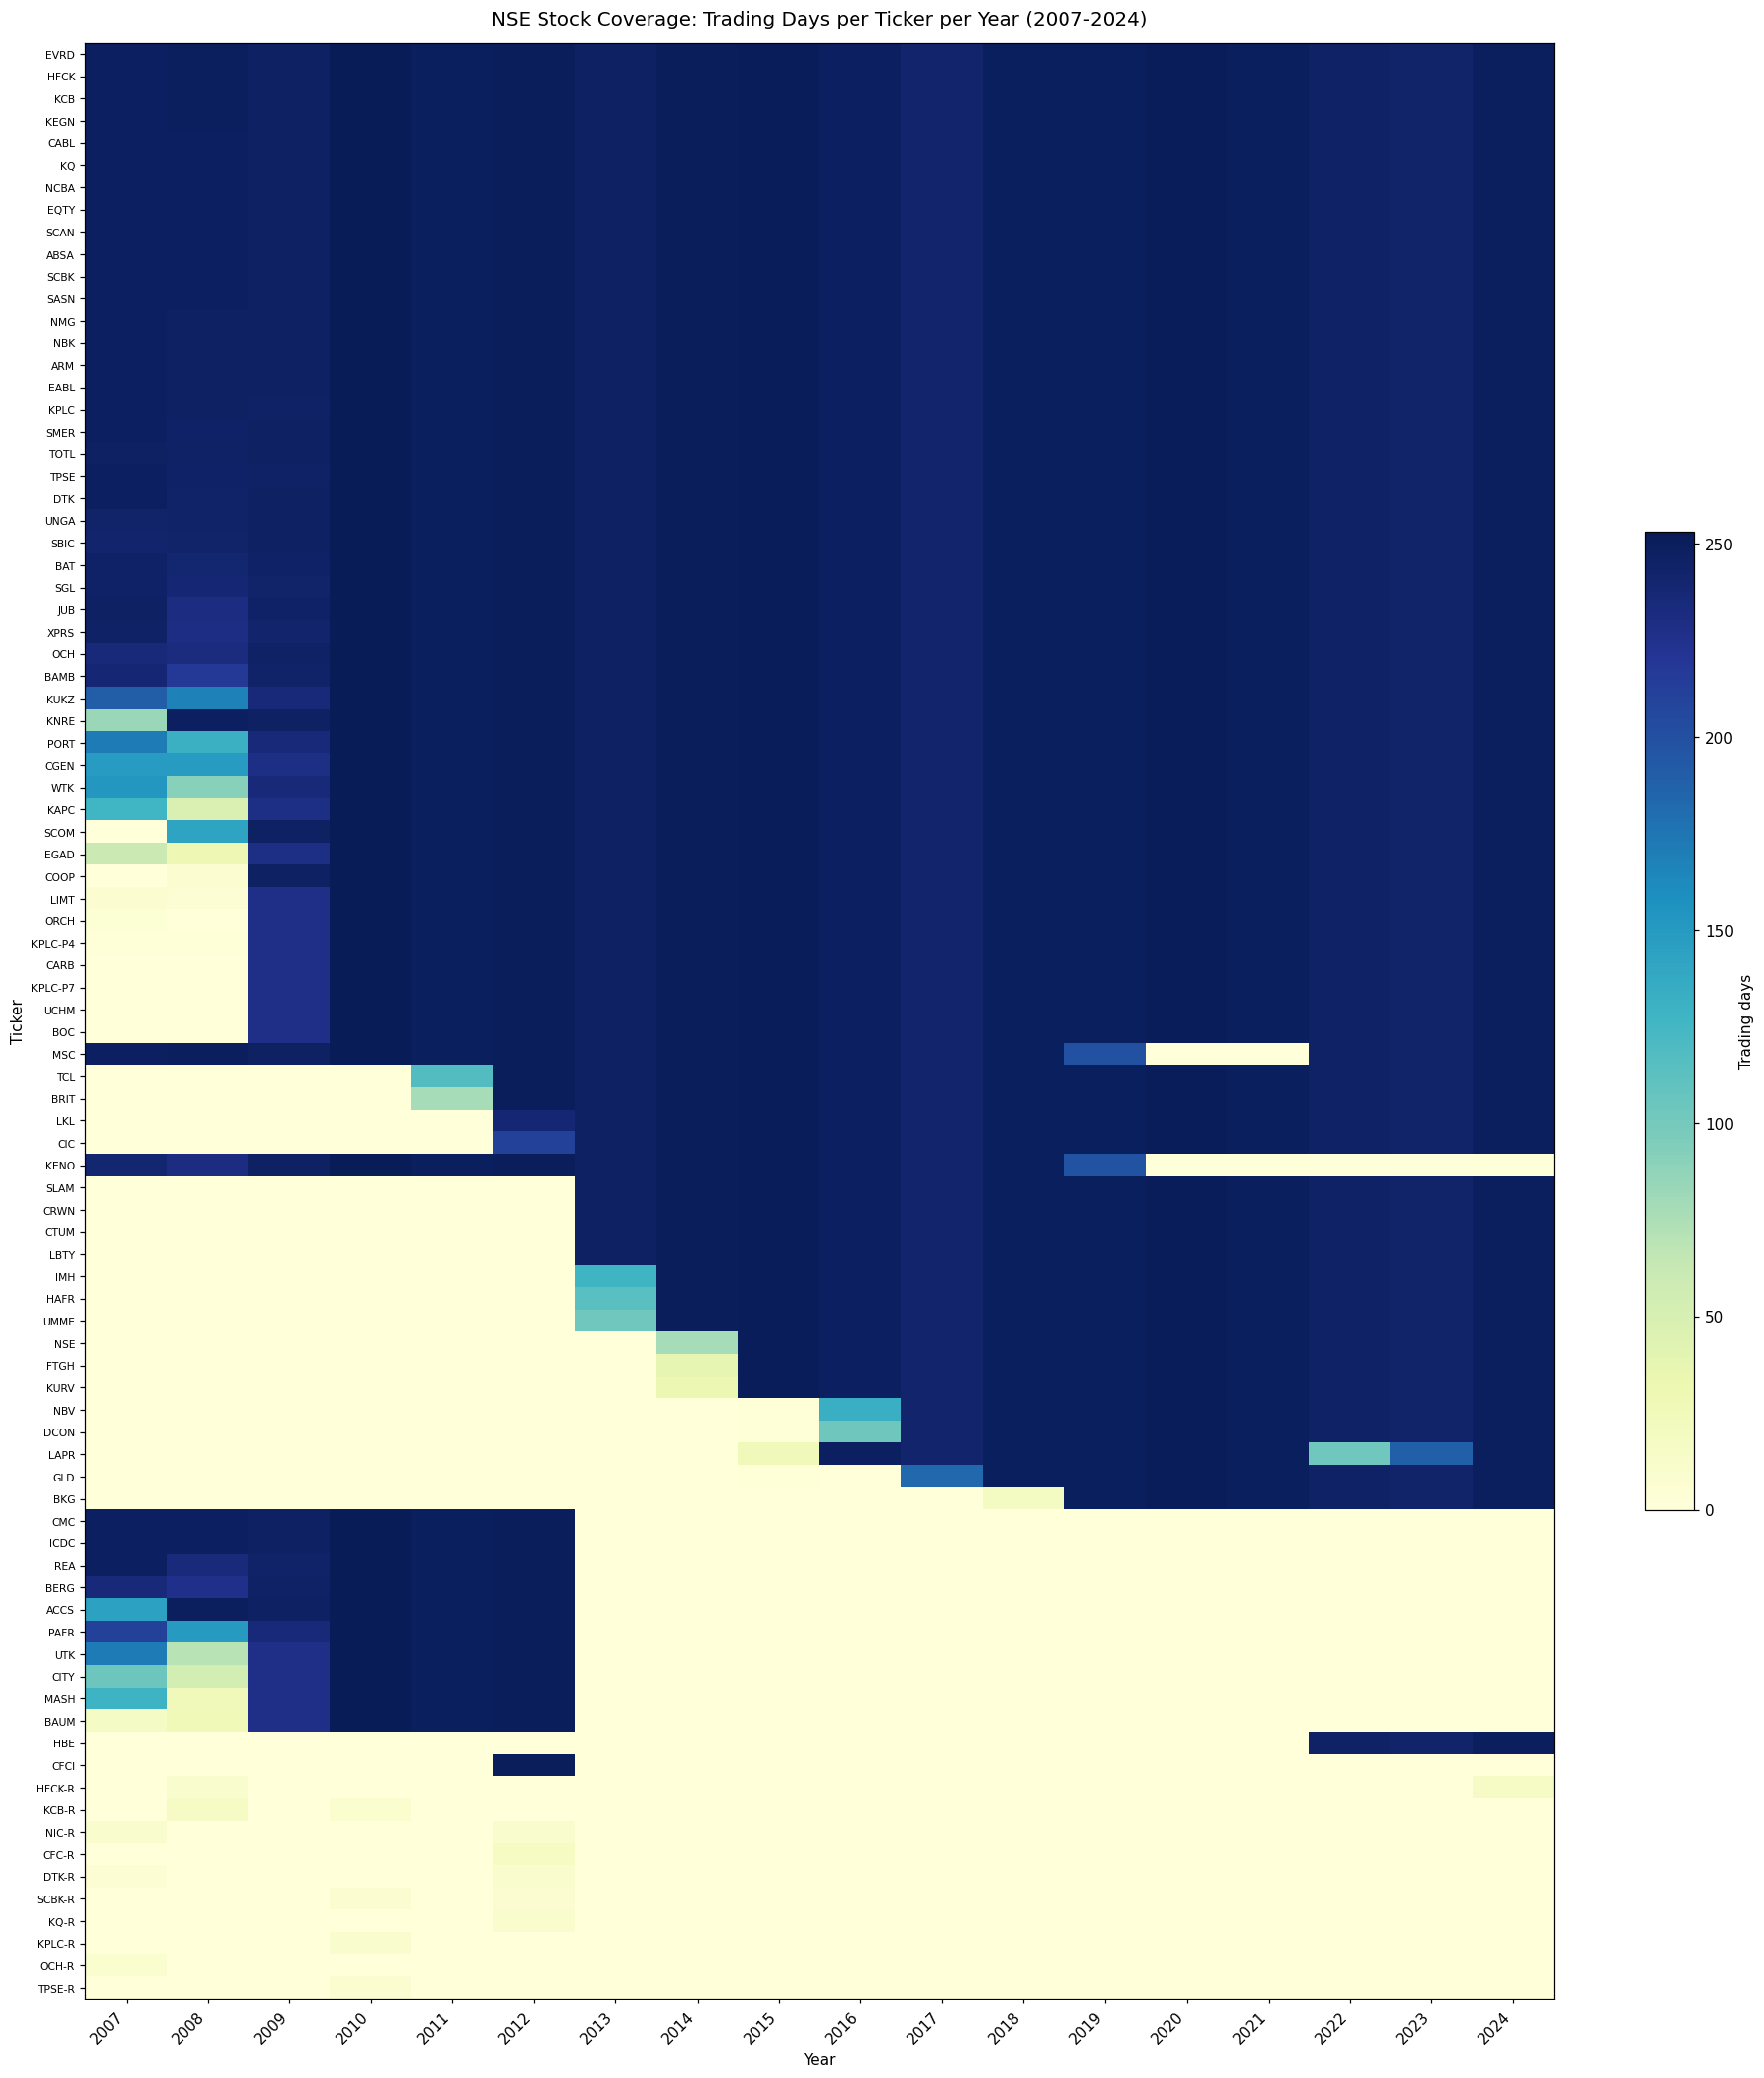

Tickers with 18-year continuous data (all years ≥ 100 days):
  32 tickers: EVRD, HFCK, KCB, KEGN, CABL, KQ, NCBA, EQTY, SCAN, ABSA, SCBK, SASN, NMG, NBK, ARM, EABL, KPLC, SMER, TOTL, TPSE, DTK, UNGA, SBIC, BAT, SGL, JUB, XPRS, OCH, BAMB, KUKZ, PORT, CGEN

Tickers with data in 2024 only (new listings):
  None


In [6]:
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#fafafa",
    "font.size": 10,
    "figure.dpi": 110,
})

prices["year"] = prices["date"].dt.year

# Trading days per ticker per year
coverage = prices.groupby(["ticker", "year"]).size().unstack(fill_value=0)

# Sort tickers by total trading days (most active first)
coverage = coverage.loc[coverage.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(18, max(10, len(coverage) * 0.22)))
im = ax.imshow(
    coverage.values,
    aspect="auto",
    cmap="YlGnBu",
    interpolation="nearest",
)
ax.set_yticks(range(len(coverage)))
ax.set_yticklabels(coverage.index, fontsize=7)
ax.set_xticks(range(len(coverage.columns)))
ax.set_xticklabels(coverage.columns, rotation=45, ha="right")
ax.set_title("NSE Stock Coverage: Trading Days per Ticker per Year (2007-2024)", fontsize=13, pad=12)
ax.set_xlabel("Year")
ax.set_ylabel("Ticker")
plt.colorbar(im, ax=ax, label="Trading days", shrink=0.5)
plt.tight_layout()
plt.show()

# Summary stats
print(f"Tickers with 18-year continuous data (all years ≥ 100 days):")
full_coverage = coverage[(coverage > 100).all(axis=1)]
print(f"  {len(full_coverage)} tickers: {', '.join(full_coverage.index.tolist())}")

print(f"\nTickers with data in 2024 only (new listings):")
recent_only = coverage[(coverage.iloc[:, :-2] == 0).all(axis=1) & (coverage.iloc[:, -1] > 0)]
if len(recent_only):
    print(f"  {', '.join(recent_only.index.tolist())}")
else:
    print("  None")

## 6. Compute Baseline Features

For each ticker on each day, calculate:
- `ret_1d` — daily return (log)
- `ret_5d` — 5-day (weekly) return
- `ret_21d` — 21-day (monthly) return
- `vol_21d` — 21-day rolling volatility (annualized)
- `ma_20`, `ma_50`, `ma_200` — moving averages
- `zscore_20` — z-score of price relative to 20-day MA and std

In [7]:
TRADING_DAYS_PER_YEAR = 252

prices = prices.sort_values(["ticker", "date"]).reset_index(drop=True)

# Log returns (compounding-safe, as Simons' team used)
prices["ret_1d"] = prices.groupby("ticker")["close"].transform(
    lambda x: np.log(x / x.shift(1))
)

# Multi-period returns
prices["ret_5d"] = prices.groupby("ticker")["close"].transform(
    lambda x: np.log(x / x.shift(5))
)
prices["ret_21d"] = prices.groupby("ticker")["close"].transform(
    lambda x: np.log(x / x.shift(21))
)

# Rolling volatility (annualized)
prices["vol_21d"] = prices.groupby("ticker")["ret_1d"].transform(
    lambda x: x.rolling(21, min_periods=15).std() * np.sqrt(TRADING_DAYS_PER_YEAR)
)

# Moving averages
for window in (20, 50, 200):
    col = f"ma_{window}"
    prices[col] = prices.groupby("ticker")["close"].transform(
        lambda x, w=window: x.rolling(w, min_periods=int(w * 0.8)).mean()
    )

# Z-score: how far price is from its 20-day MA in units of 20-day std
roll_std_20 = prices.groupby("ticker")["close"].transform(
    lambda x: x.rolling(20, min_periods=15).std()
)
prices["zscore_20"] = (prices["close"] - prices["ma_20"]) / roll_std_20.replace(0, np.nan)

# Quick sanity check
print("Feature columns added:")
feature_cols = ["ret_1d", "ret_5d", "ret_21d", "vol_21d", "ma_20", "ma_50", "ma_200", "zscore_20"]
print(prices[feature_cols].describe().round(4).to_string())

Feature columns added:


            ret_1d       ret_5d      ret_21d      vol_21d        ma_20        ma_50       ma_200    zscore_20
count  267222.0000  266870.0000  265531.0000  266017.0000  266017.0000  264121.0000  254761.0000  239244.0000
mean       -0.0004      -0.0017      -0.0073       0.8041      90.3092      90.1917      89.7604      -0.0651
std         0.0892       0.1462       0.1478       1.1778     240.0730     239.0780     234.5965       1.2100
min        -3.0487      -5.7526      -7.1740       0.0000       0.1745       0.1808       0.1892      -4.2485
25%        -0.0079      -0.0274      -0.0533       0.2338       7.1380       7.2032       7.3770      -0.8753
50%         0.0000       0.0000       0.0000       0.4641      20.2725      20.3240      20.5855      -0.1037
75%         0.0066       0.0231       0.0382       0.8840      70.6000      70.6200      72.3862       0.7198
max         2.8965       3.0014       2.8965      19.0941    3275.0000    3245.2000    2997.7750       4.2485


## 6b. Return Distributions (Daily / Weekly / Monthly)

How fat-tailed are NSE returns? How do they compare across horizons?
This tells us whether standard risk models (which assume normal distributions) will
work or if we need robust methods.

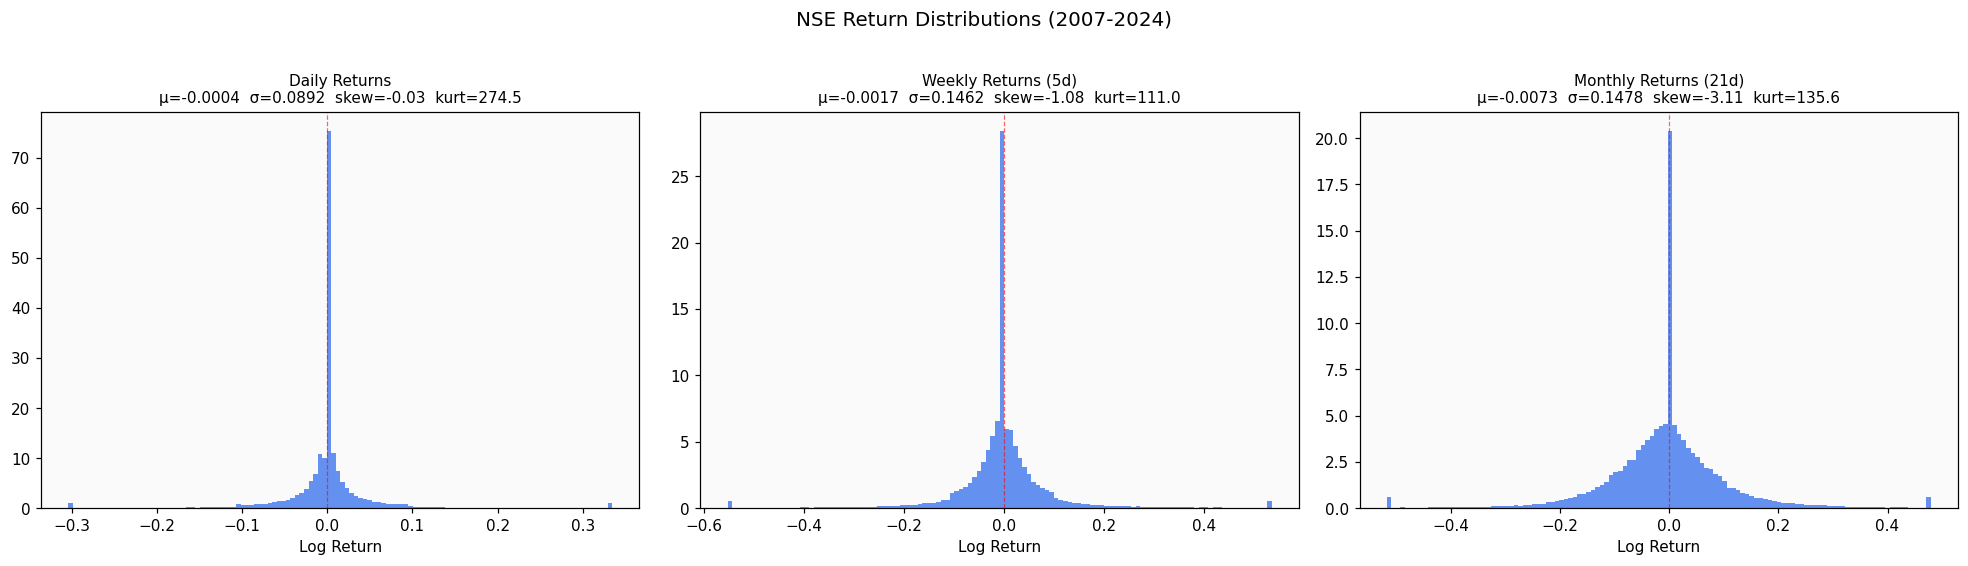

,Horizon,Count,Mean,Std,Skewness,Kurtosis,Min,Max
0,Daily,267222,-0.00038,0.0892,-0.034,274.5,-3.0487,2.8965
1,Weekly,266870,-0.00175,0.1462,-1.083,111.0,-5.7526,3.0014
2,Monthly,265531,-0.00725,0.1478,-3.107,135.6,-7.1740,2.8965


In [8]:
from scipy import stats as sp_stats

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (col, label) in zip(axes, [
    ("ret_1d", "Daily Returns"),
    ("ret_5d", "Weekly Returns (5d)"),
    ("ret_21d", "Monthly Returns (21d)"),
]):
    data = prices[col].dropna()
    # Clip extreme outliers for visualization
    data_clipped = data.clip(data.quantile(0.005), data.quantile(0.995))

    ax.hist(data_clipped, bins=120, density=True, alpha=0.7, color="#2563eb", edgecolor="none")

    mu, sigma = data.mean(), data.std()
    kurt = data.kurtosis()
    skew = data.skew()

    ax.set_title(f"{label}\nμ={mu:.4f}  σ={sigma:.4f}  skew={skew:.2f}  kurt={kurt:.1f}", fontsize=10)
    ax.set_xlabel("Log Return")
    ax.axvline(0, color="red", linewidth=0.8, linestyle="--", alpha=0.6)

plt.suptitle("NSE Return Distributions (2007-2024)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Summary table
ret_summary = []
for col, label in [("ret_1d", "Daily"), ("ret_5d", "Weekly"), ("ret_21d", "Monthly")]:
    d = prices[col].dropna()
    ret_summary.append({
        "Horizon": label,
        "Count": len(d),
        "Mean": f"{d.mean():.5f}",
        "Std": f"{d.std():.4f}",
        "Skewness": f"{d.skew():.3f}",
        "Kurtosis": f"{d.kurtosis():.1f}",
        "Min": f"{d.min():.4f}",
        "Max": f"{d.max():.4f}",
    })
pd.DataFrame(ret_summary)

## 7. Volatility and Drawdown Profiles by Sector

Which sectors are the most volatile? Which recover from drawdowns fastest?
Key input for regime detection and risk-adjusted portfolio weighting later.

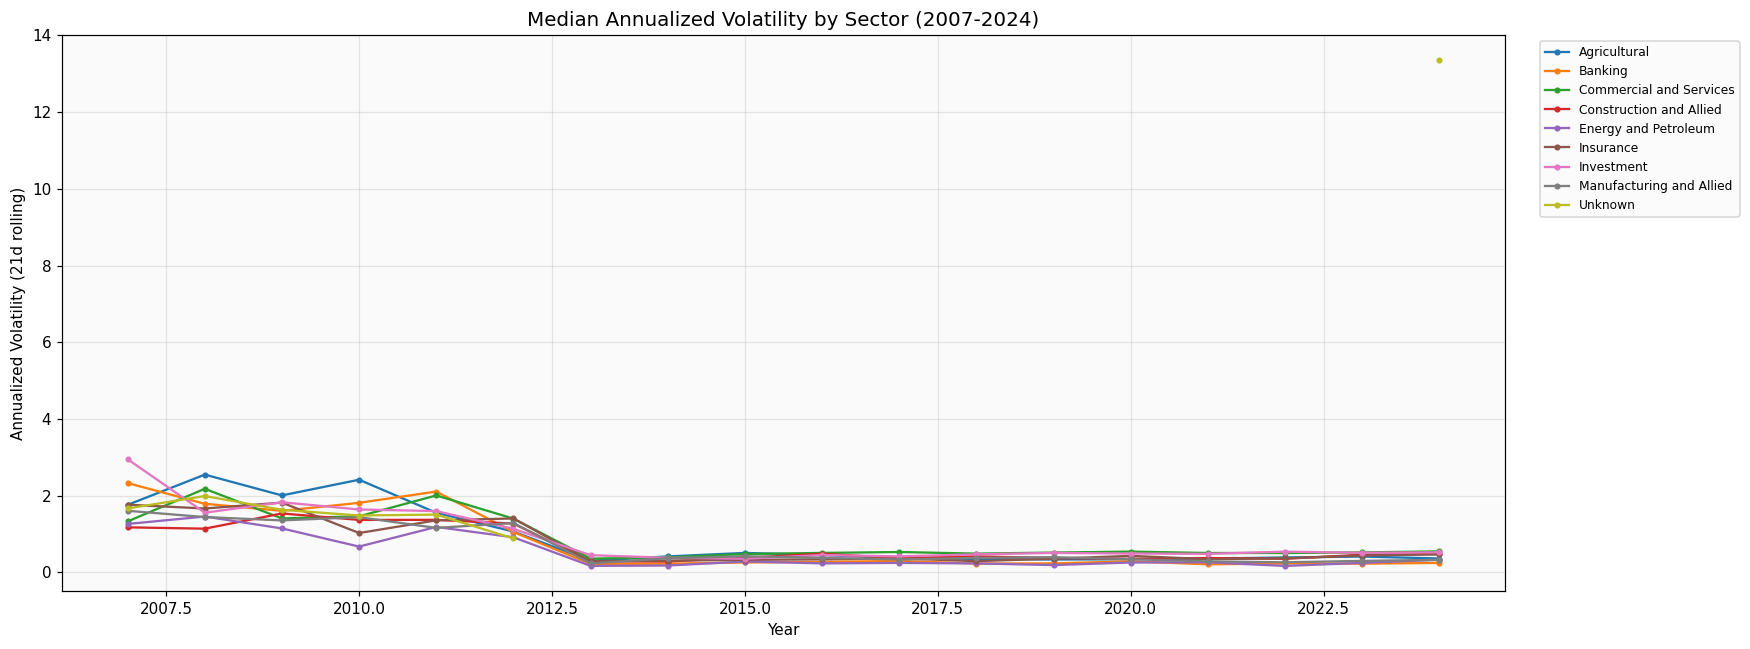

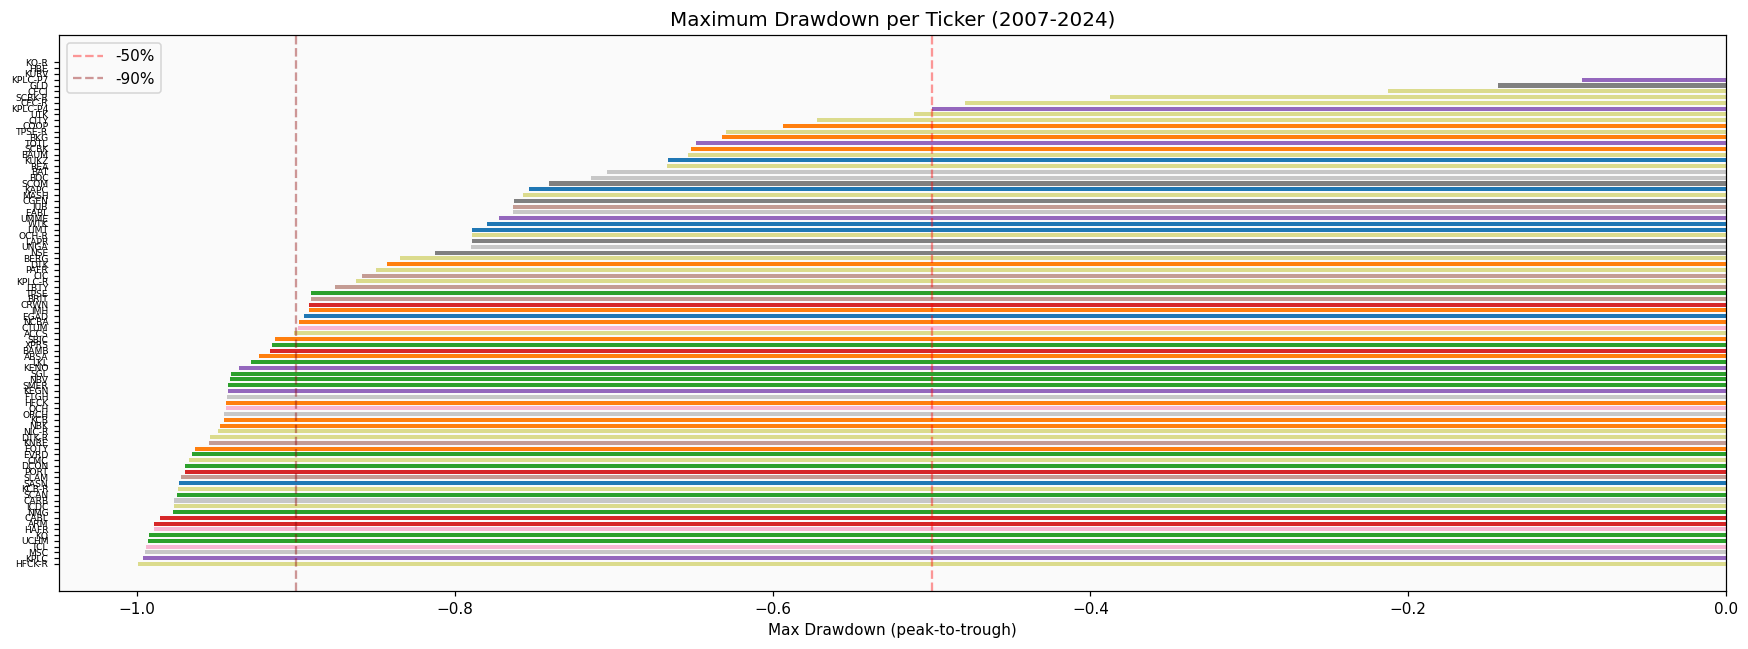

Sector Drawdown Summary (negative = deeper drawdown):
                               Median DD  Worst DD  # Tickers
sector                                                       
Construction and Allied        -0.970067 -0.989149          5
Investment                     -0.944127 -0.994386          5
Commercial and Services        -0.942667 -0.993118         13
Banking                        -0.905629 -0.963426         12
Insurance                      -0.883108 -0.972340          6
Manufacturing and Allied       -0.866795 -0.994953          8
Investment Services            -0.812544 -0.812544          1
Real Estate Investment Trusts  -0.789474 -0.789474          1
Unknown                        -0.789474 -0.999234         21
Agricultural                   -0.784584 -0.973510          6
Energy and Petroleum           -0.772500 -0.996364          7
Automobiles and Accessories    -0.762963 -0.762963          1
Telecommunication              -0.740823 -0.740823          1
Exchange Traded 

In [9]:
# --- Sector volatility ---
# Median annualized volatility per sector per year
sector_vol = (
    prices.groupby(["sector", "year"])["vol_21d"]
    .median()
    .unstack(fill_value=np.nan)
)

fig, ax = plt.subplots(figsize=(16, 6))
# Plot only major sectors (exclude Unknown and tiny categories)
major_sectors = ticker_master.groupby("sector")["ticker"].count()
major_sectors = major_sectors[major_sectors >= 3].index.tolist()
for sector in major_sectors:
    if sector in sector_vol.index:
        ax.plot(sector_vol.columns, sector_vol.loc[sector], marker="o", markersize=3, label=sector)

ax.set_title("Median Annualized Volatility by Sector (2007-2024)", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("Annualized Volatility (21d rolling)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- Max drawdown per ticker ---
def max_drawdown(series: pd.Series) -> float:
    """Maximum peak-to-trough drawdown."""
    cummax = series.cummax()
    dd = (series - cummax) / cummax
    return float(dd.min()) if len(dd) > 0 else 0.0

ticker_dd = (
    prices.groupby("ticker")["close"]
    .apply(max_drawdown)
    .sort_values()
)

# Merge with sector for context
dd_df = ticker_dd.reset_index()
dd_df.columns = ["ticker", "max_drawdown"]
dd_df = dd_df.merge(ticker_master[["ticker", "sector"]], on="ticker", how="left")

fig, ax = plt.subplots(figsize=(16, 6))
colors = dd_df["sector"].map(
    {s: plt.cm.tab20(i / len(major_sectors)) for i, s in enumerate(major_sectors)}
).fillna("gray")
ax.barh(range(len(dd_df)), dd_df["max_drawdown"], color=colors, height=0.7)
ax.set_yticks(range(len(dd_df)))
ax.set_yticklabels(dd_df["ticker"], fontsize=6)
ax.set_xlabel("Max Drawdown (peak-to-trough)")
ax.set_title("Maximum Drawdown per Ticker (2007-2024)", fontsize=13)
ax.axvline(-0.5, color="red", linestyle="--", alpha=0.4, label="-50%")
ax.axvline(-0.9, color="darkred", linestyle="--", alpha=0.4, label="-90%")
ax.legend()
plt.tight_layout()
plt.show()

# Sector drawdown summary
sector_dd = dd_df.groupby("sector")["max_drawdown"].agg(["median", "min", "count"])
sector_dd.columns = ["Median DD", "Worst DD", "# Tickers"]
sector_dd = sector_dd.sort_values("Median DD")
print("Sector Drawdown Summary (negative = deeper drawdown):")
print(sector_dd.to_string())

## 8. Cross-Sectional Leaders and Laggards

Who were the best and worst performers over rolling windows? This is the raw material
for momentum and mean-reversion signal testing in the next phase.

C:\Users\KEVIN\AppData\Local\Temp\ipykernel_28148\2104064503.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ticker_cagr = prices.groupby("ticker").apply(cagr).sort_values(ascending=False)


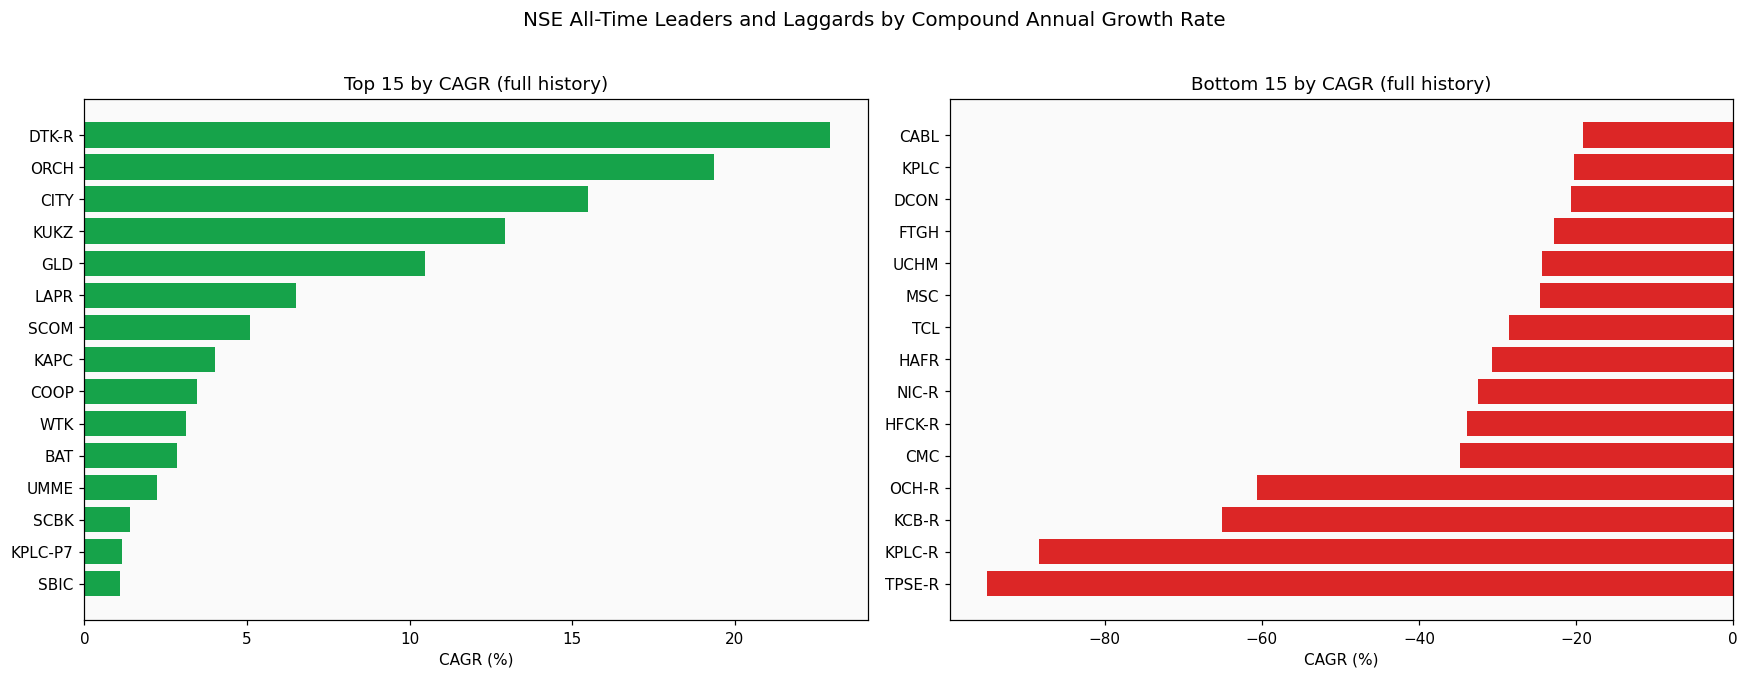


Top 20 Tickers by Risk-Adjusted Performance
           CAGR  Sharpe   MaxDD                         sector  composite
ticker                                                                   
GLD      0.1048  0.7826 -0.1436          Exchange Traded Funds     0.9741
CITY     0.1550  0.0983 -0.5722                        Unknown     0.9494
KUKZ     0.1292  0.1013 -0.6658                   Agricultural     0.9282
KPLC-P7  0.0115  0.0920 -0.0909           Energy and Petroleum     0.9141
COOP     0.0346  0.0360 -0.5938                        Banking     0.8976
SCOM     0.0508  0.0499 -0.7408              Telecommunication     0.8900
LAPR     0.0649  0.1102 -0.7895  Real Estate Investment Trusts     0.8832
KAPC     0.0400  0.0482 -0.7531                   Agricultural     0.8782
BAT      0.0284  0.0320 -0.7044       Manufacturing and Allied     0.8606
SCBK     0.0140  0.0167 -0.6514                        Banking     0.8547
UMME     0.0224  0.0461 -0.7725           Energy and Petroleum     

In [10]:
# Full-period CAGR per ticker (using first and last available close)
def cagr(group: pd.DataFrame) -> float:
    group = group.sort_values("date")
    first_price = group["close"].iloc[0]
    last_price = group["close"].iloc[-1]
    days = (group["date"].iloc[-1] - group["date"].iloc[0]).days
    if days <= 0 or first_price <= 0:
        return np.nan
    years = days / 365.25
    return (last_price / first_price) ** (1 / years) - 1

ticker_cagr = prices.groupby("ticker").apply(cagr).sort_values(ascending=False)
ticker_cagr = ticker_cagr.dropna()

# Top 15 and Bottom 15 by CAGR
n_show = 15
top = ticker_cagr.head(n_show)
bottom = ticker_cagr.tail(n_show)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.barh(range(len(top)), top.values * 100, color="#16a34a")
ax1.set_yticks(range(len(top)))
ax1.set_yticklabels(top.index)
ax1.set_xlabel("CAGR (%)")
ax1.set_title(f"Top {n_show} by CAGR (full history)", fontsize=12)
ax1.invert_yaxis()

ax2.barh(range(len(bottom)), bottom.values * 100, color="#dc2626")
ax2.set_yticks(range(len(bottom)))
ax2.set_yticklabels(bottom.index)
ax2.set_xlabel("CAGR (%)")
ax2.set_title(f"Bottom {n_show} by CAGR (full history)", fontsize=12)
ax2.invert_yaxis()

plt.suptitle("NSE All-Time Leaders and Laggards by Compound Annual Growth Rate", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Sharpe ratio approximation per ticker
ticker_sharpe = (
    prices.groupby("ticker")["ret_1d"]
    .agg(lambda x: x.mean() / x.std() * np.sqrt(TRADING_DAYS_PER_YEAR) if x.std() > 0 else np.nan)
    .sort_values(ascending=False)
    .dropna()
)

# Combined scorecard
scorecard = pd.DataFrame({
    "CAGR": ticker_cagr,
    "Sharpe": ticker_sharpe,
    "MaxDD": ticker_dd,
}).dropna()
scorecard = scorecard.merge(ticker_master[["ticker", "sector"]], left_index=True, right_on="ticker", how="left")
scorecard = scorecard.set_index("ticker")

print(f"\n{'='*70}")
print(f"Top 20 Tickers by Risk-Adjusted Performance")
print(f"{'='*70}")
# Rank by composite: normalize each metric to [0,1] then average
for col in ["CAGR", "Sharpe"]:
    scorecard[f"{col}_rank"] = scorecard[col].rank(pct=True)
# MaxDD is negative, so higher (less negative) is better
scorecard["MaxDD_rank"] = scorecard["MaxDD"].rank(pct=True)
scorecard["composite"] = (
    scorecard["CAGR_rank"] * 0.4 +
    scorecard["Sharpe_rank"] * 0.35 +
    scorecard["MaxDD_rank"] * 0.25
)
scorecard = scorecard.sort_values("composite", ascending=False)
print(scorecard[["CAGR", "Sharpe", "MaxDD", "sector", "composite"]].head(20).to_string(float_format="%.4f"))

## 9. Save Artifacts

Persist the canonical dataset and ticker master as parquet files, and generate
markdown quality and summary reports.

In [11]:
# Save parquet artifacts
prices.to_parquet(RESEARCH_DATA / "canonical_nse_prices.parquet", index=False)
ticker_master.to_parquet(RESEARCH_DATA / "ticker_master.parquet", index=False)
print(f"Saved: {RESEARCH_DATA / 'canonical_nse_prices.parquet'}")
print(f"Saved: {RESEARCH_DATA / 'ticker_master.parquet'}")

# --- Generate phase1_data_quality.md ---
dq_lines = [
    "# Phase 1A — Data Quality Report\n",
    f"Generated from `01_data_foundation.ipynb`\n",
    "## Raw Data Summary\n",
]
for k, v in quality_report.items():
    dq_lines.append(f"- **{k}**: {v:,}" if isinstance(v, int) else f"- **{k}**: {v}")
dq_lines.append("\n## Cleaning Applied\n")
dq_lines.append(f"- Removed exact duplicate (date, ticker) pairs")
dq_lines.append(f"- Removed rows with missing or non-positive close prices")
dq_lines.append(f"- Final dataset: **{len(prices):,}** rows\n")
dq_lines.append("## Coverage\n")
dq_lines.append(f"- Date range: {prices['date'].min().date()} to {prices['date'].max().date()}")
dq_lines.append(f"- Unique tickers: {prices['ticker'].nunique()}")
dq_lines.append(f"- Unique trading days: {prices['date'].dt.date.nunique()}\n")
dq_lines.append("## Sector Distribution\n")
dq_lines.append("| Sector | Tickers | Active |")
dq_lines.append("|---|---:|---:|")
for sector in sorted(ticker_master["sector"].unique()):
    s = ticker_master[ticker_master["sector"] == sector]
    dq_lines.append(f"| {sector} | {len(s)} | {s['active'].sum()} |")

dq_path = RESEARCH_REPORTS / "phase1_data_quality.md"
dq_path.write_text("\n".join(dq_lines), encoding="utf-8")
print(f"Saved: {dq_path}")

# --- Generate phase1_eda_summary.md ---
eda_lines = [
    "# Phase 1A — EDA Summary\n",
    f"Generated from `01_data_foundation.ipynb`\n",
    "## Dataset\n",
    f"- **{len(prices):,}** price observations across **{prices['ticker'].nunique()}** tickers",
    f"- Date range: **{prices['date'].min().date()}** to **{prices['date'].max().date()}**",
    f"- **{len(ticker_master)}** tickers in master map ({ticker_master['active'].sum()} currently active)\n",
    "## Return Characteristics\n",
    "| Horizon | Mean | Std | Skewness | Kurtosis |",
    "|---|---:|---:|---:|---:|",
]
for col, label in [("ret_1d", "Daily"), ("ret_5d", "Weekly"), ("ret_21d", "Monthly")]:
    d = prices[col].dropna()
    eda_lines.append(f"| {label} | {d.mean():.5f} | {d.std():.4f} | {d.skew():.3f} | {d.kurtosis():.1f} |")

eda_lines.append("\n## Top 10 by Risk-Adjusted Composite Score\n")
eda_lines.append("| Rank | Ticker | Sector | CAGR | Sharpe | Max DD | Score |")
eda_lines.append("|---:|---|---|---:|---:|---:|---:|")
for i, (ticker, row) in enumerate(scorecard.head(10).iterrows(), 1):
    eda_lines.append(
        f"| {i} | {ticker} | {row['sector']} | "
        f"{row['CAGR']*100:.1f}% | {row['Sharpe']:.2f} | "
        f"{row['MaxDD']*100:.1f}% | {row['composite']:.3f} |"
    )

eda_lines.append("\n## Bottom 10 by Composite Score\n")
eda_lines.append("| Rank | Ticker | Sector | CAGR | Sharpe | Max DD | Score |")
eda_lines.append("|---:|---|---|---:|---:|---:|---:|")
for i, (ticker, row) in enumerate(scorecard.tail(10).iterrows(), 1):
    eda_lines.append(
        f"| {i} | {ticker} | {row['sector']} | "
        f"{row['CAGR']*100:.1f}% | {row['Sharpe']:.2f} | "
        f"{row['MaxDD']*100:.1f}% | {row['composite']:.3f} |"
    )

eda_lines.append("\n## Sector Drawdown Summary\n")
eda_lines.append("| Sector | Median DD | Worst DD | Tickers |")
eda_lines.append("|---|---:|---:|---:|")
for sector, row in sector_dd.iterrows():
    eda_lines.append(f"| {sector} | {row['Median DD']*100:.1f}% | {row['Worst DD']*100:.1f}% | {int(row['# Tickers'])} |")

eda_lines.append("\n## Next Steps\n")
eda_lines.append("- Notebook 2: overlay global events and detect market regimes")
eda_lines.append("- Test momentum and mean-reversion signals on this clean dataset")
eda_lines.append("- Integrate live Supabase data for forward-looking analysis")

eda_path = RESEARCH_REPORTS / "phase1_eda_summary.md"
eda_path.write_text("\n".join(eda_lines), encoding="utf-8")
print(f"Saved: {eda_path}")
print("\n✓ All Phase 1A artifacts generated.")

Saved: D:\2026 Projects\Nairobi-stock-Exchange\research\data\canonical_nse_prices.parquet
Saved: D:\2026 Projects\Nairobi-stock-Exchange\research\data\ticker_master.parquet
Saved: D:\2026 Projects\Nairobi-stock-Exchange\research\reports\phase1_data_quality.md


Saved: D:\2026 Projects\Nairobi-stock-Exchange\research\reports\phase1_eda_summary.md

✓ All Phase 1A artifacts generated.
